# Vežbe 3: Linearna regresija pomoću jednostavne neuronske mreže u biblioteci PyTorch

U ovom notebook-u fokus je na **kreiranju i razumevanju najjednostavnije neuronske mreže** za problem linearne regresije.

Cilj je da kroz jednostavan primer prikažemo kako neuronska mreža može da nauči linearnu funkciju oblika:

**y = wx + b**

Prolazimo kroz sledeće korake:
- generisanje sintetičkog skupa podataka,
- definisanje modela,
- definisanje funkcije greške i optimizacionog algoritma,
- treniranje modela,
- prikaz naučenih parametara,
- vizuelizaciju rezultata.

Na kraju, trebalo bi da model nauči vrednosti parametara koje su bliske stvarnoj funkciji korišćenoj za generisanje podataka.

In [1]:
# Import potrebnih biblioteka

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd


## 1. Postavljanje seed-a za reproduktivnost rezultata


In [2]:
# Postaviti seed

torch.manual_seed(42)

## 2. Generisanje sintetičkog skupa podataka

U ovom primeru koristimo jednostavan, veštački generisan skup podataka zasnovan na linearnoj funkciji:

**y = 2x + 1 + šum**

In [3]:
# Generisati sintetički skup podataka za linearnu funkciju y = 2x + 1 uz dodatak šuma (kako bi podaci izgledali realističnije)

X = torch.arange(0, 10, 0.1).reshape(100, 1)

noise = torch.randn(100, 1) * 0.8

y = 2 * X + 1 + noise

In [4]:
print(type(X))
print(type(y))
print(X[:5])
print(y[:5])

<class 'torch.Tensor'>
<class 'torch.Tensor'>
tensor([[0.0000],
        [0.1000],
        [0.2000],
        [0.3000],
        [0.4000]])
tensor([[ 2.5415],
        [ 2.3898],
        [ 2.1206],
        [-0.0844],
        [ 2.3427]])


## 3. Vizualizacija podataka

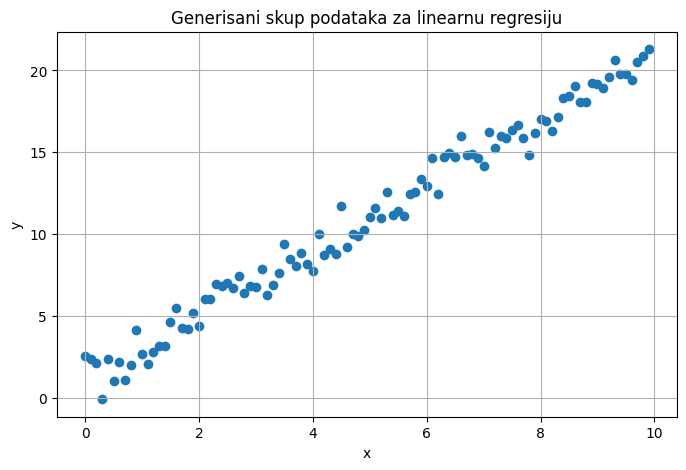

In [5]:
# Nacrtati scatter plot za generisane podatake

plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy())
plt.xlabel("x")
plt.ylabel("y")
plt.title("Generisani skup podataka za linearnu regresiju")
plt.grid(True)
plt.show()

## 4. Definisanje modela

In [6]:
# Definisati klasu neuronske mreže za linearnu regresiju koja se sastoji od jednog linearnog sloja sa jednim ulazom i jednim izlazom

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

In [7]:
# Kreirati instancu definisanog modela

model = LinearRegressionModel()

In [8]:
# Prikazati početne vrednosti parametara modela (težine i bias)

print("Početna težina:", model.linear.weight.item())
print("Početni bias:", model.linear.bias.item())

Početna težina: 0.1563711166381836
Početni bias: -0.8799213171005249


## 5. Definisanje funkcije greške i optimizacionog algoritma

In [9]:
# Definisati MSE funkciju greške i SGD optimizacioni algoritam

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## 6. Trening modela


In [10]:
# Istrenirati model

num_epochs = 1000

for epoch in range(num_epochs):
    # Predikcija modela (forward pass)
    y_pred = model(X)

    # Izračunavanje greške
    loss = criterion(y_pred, y)

    # Brisanje prethodnih gradijenata
    optimizer.zero_grad()

    # Izračunavanje gradijenata
    loss.backward()

    # Ažuriranje parametara modela
    optimizer.step()

    # Ispis greške na svakoj 100. epohi radi praćenja napretka treniranja
    if (epoch + 1) % 100 == 0:
        print("Epoha:", epoch + 1, "Greška:", loss.item())

Epoha: 100 Greška: 0.8694441318511963
Epoha: 200 Greška: 0.7098835706710815
Epoha: 300 Greška: 0.6508796215057373
Epoha: 400 Greška: 0.629060685634613
Epoha: 500 Greška: 0.6209923028945923
Epoha: 600 Greška: 0.6180086731910706
Epoha: 700 Greška: 0.6169052720069885
Epoha: 800 Greška: 0.616497278213501
Epoha: 900 Greška: 0.616346538066864
Epoha: 1000 Greška: 0.6162907481193542


## 7. Prikaz naučenih parametara

In [11]:
# Prikazati naučene vrednosti parametara modela (težine i bias-a)

weight = model.linear.weight.item()
bias = model.linear.bias.item()

print("Naučena težina:", weight)
print("Naučeni bias:", bias)

Naučena težina: 1.996953010559082
Naučeni bias: 1.0600916147232056


## 8. Vizuelni prikaz naučene regresione prave

In [12]:
# Generisati izlaze modela za sve ulazne vrednosti radi prikaza naučene regresione prave

with torch.no_grad():
    y_pred = model(X)

print(y_pred[:5])

tensor([[1.0601],
        [1.2598],
        [1.4595],
        [1.6592],
        [1.8589]])


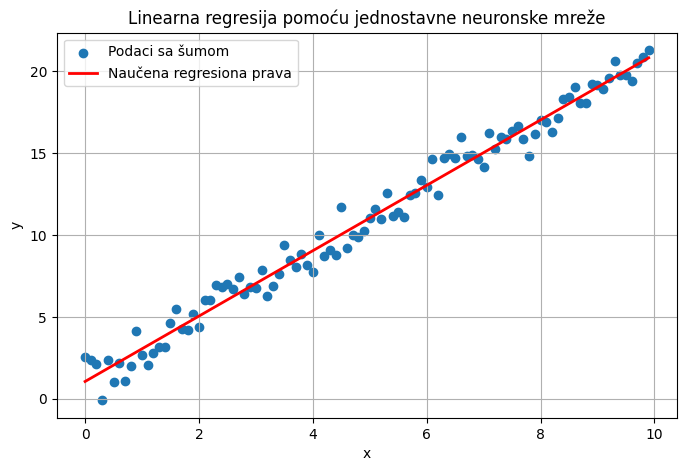

In [13]:
# Nacrtati originalne podatke i regresionu pravu koju je model naučio

plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), label="Podaci sa šumom")
plt.plot(X.numpy(), y_pred.numpy(), color="red", linewidth=2, label="Naučena regresiona prava")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linearna regresija pomoću jednostavne neuronske mreže")
plt.legend()
plt.grid(True)
plt.show()

## 9. Predikcija za novu vrednost

In [14]:
# Napraviti novu ulaznu vrednost i izračunati odgovarajuću predikciju modela

new_X = torch.tensor([12.0])

with torch.no_grad():
    new_y = model(new_X)

print("Predikcija za x = 12:", new_y.item())

Predikcija za x = 12: 25.023527145385742


# Samostalni rad

* Vizualizovati promenu greške kroz epohe (loss curve)
* Eksperimentisati sa različitim brojem epoha i posmatrati kako to utiče na grešku (MSE)
* Menjati vrednost learning rate-a i analizirati njegov uticaj na proces treniranja i konačnu grešku
* Izmeniti funkciju koja generiše podatke (parametre k i n) i povećati nivo šuma (noise)
* Dodati outlijere u podatke
* Podeliti skup podataka na trening i test skup, izračunati MSE za oba
* Izračunati R² (koeficijent determinacije)
* Iscrtati predikcije modela na test skupu i uporediti ih sa stvarnim vrednostima